# CapexQuant SABI Castellón

## Tested financial-data pipeline for heterogeneous company information

CapexQuant is a reproducible financial analytics project designed to clean,
validate and analyse company-level information while preserving data-quality
controls, methodological traceability and source confidentiality.

This public notebook uses a fully synthetic dataset. It contains no SABI
records, real companies or personal information.

## 1. Project objectives

CapexQuant demonstrates how to:

- validate heterogeneous company-level information;
- preserve a standardized and auditable schema;
- clean company names and legal-status markers deterministically;
- calculate revenue growth, EBITDA margins and productivity metrics;
- distinguish data-quality problems from business-risk signals;
- compare different analytical scopes;
- measure revenue concentration;
- aggregate results geographically;
- reproduce the complete analysis without redistributing licensed data.

The public dataset contains fictional companies and simplified financial
relationships. It is intended exclusively for demonstration, testing and
recruitment review.

In [37]:
from pathlib import Path
import sys

CURRENT_DIRECTORY = Path.cwd().resolve()

if CURRENT_DIRECTORY.name == "notebooks":
    PROJECT_ROOT = CURRENT_DIRECTORY.parent
else:
    PROJECT_ROOT = CURRENT_DIRECTORY

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"Project root detected: {PROJECT_ROOT.name}")

Project root detected: capexquant-sabi-castellon


In [38]:
from src.pipeline import run_pipeline

result = run_pipeline(
    source="synthetic",
    ranking_size=20,
)

print("CapexQuant pipeline completed successfully.")
print(f"Source: {result.source_name}")
print(f"Rows processed: {result.row_count:,}")
print(f"Final company-level columns: {result.final_column_count}")
print(f"Analytical tables: {len(result.analytical_tables)}")

CapexQuant pipeline completed successfully.
Source: synthetic
Rows processed: 120
Final company-level columns: 36
Analytical tables: 7


## 2. Pipeline architecture

```text
Fully synthetic public source
            ↓
Standardized ten-column schema
            ↓
Deterministic data cleaning
            ↓
Financial feature engineering
            ↓
Data-quality and business-risk controls
            ↓
Analytical aggregation
            ↓
Tables, rankings and visualizations

In [39]:
pipeline_dimensions = {
    "source": result.source_dataframe.shape,
    "clean": result.clean_dataframe.shape,
    "financial": result.financial_dataframe.shape,
    "quality": result.quality_dataframe.shape,
}

pipeline_dimensions

{'source': (120, 10),
 'clean': (120, 16),
 'financial': (120, 28),
 'quality': (120, 36)}

## 3. Data coverage

Coverage measures the proportion of records available for each analytical
variable. Missing financial information is preserved as missing data and is
never interpreted as an economic zero.

This distinction is essential because replacing unavailable information with
zero would distort growth, profitability and productivity calculations.

In [40]:
coverage = result.get_table("coverage")
coverage

,variable,available_records,missing_records,coverage_rate
0,employees_latest,120,0,1.000000
1,operating_revenue_latest_k_eur,117,3,0.975000
2,ebitda_latest_k_eur,118,2,0.983333
3,revenue_growth,116,4,0.966667
4,ebitda_margin,117,3,0.975000


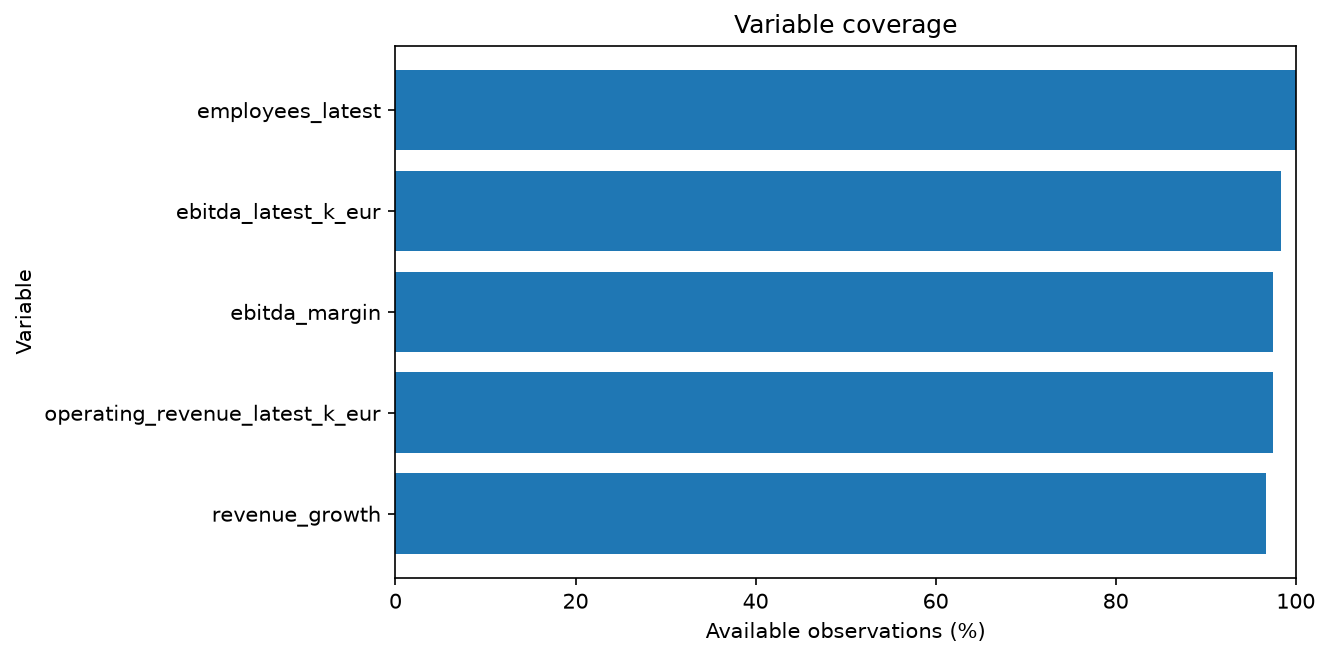

In [41]:
from IPython.display import Image, display

FIGURES_DIRECTORY = (
    PROJECT_ROOT
    / "reports"
    / "figures"
)

display(
    Image(
        filename=str(
            FIGURES_DIRECTORY
            / "coverage.png"
        )
    )
)

## 4. Data quality and business risk

CapexQuant separates two concepts that should not be treated as equivalent:

### Data-quality issue

A condition that may limit the reliability or conventional usability of a
record, such as incomplete financial information, an extreme EBITDA margin or
a potential duplicate.

### Business-risk signal

An economically or legally adverse characteristic, such as negative EBITDA,
declining revenue or an explicit adverse legal-status marker.

A company may contain reliable data and still present substantial business
risk. Negative performance is not automatically a data error.

In [42]:
quality_summary = result.get_table(
    "quality_summary"
)

quality_summary

,indicator,record_count,record_percentage
0,has_incomplete_financial_data,4,0.033333
1,has_negative_latest_revenue,0,0.000000
2,has_zero_latest_revenue,0,0.000000
3,has_extreme_ebitda_margin,0,0.000000
4,potential_duplicate,0,0.000000
5,has_adverse_legal_status,8,0.066667
6,has_negative_latest_ebitda,21,0.175000
7,has_revenue_decline,44,0.366667
8,has_data_quality_issue,4,0.033333
9,has_business_risk_signal,61,0.508333


In [43]:
quality_dataframe = result.quality_dataframe

quality_status_distribution = (
    quality_dataframe["data_quality_status"]
    .value_counts()
    .rename_axis("data_quality_status")
    .reset_index(name="company_count")
)

eligibility_distribution = (
    quality_dataframe["analytical_eligibility"]
    .value_counts()
    .rename_axis("analytical_eligibility")
    .reset_index(name="company_count")
)

display(quality_status_distribution)
display(eligibility_distribution)

,data_quality_status,company_count
0,clean,116
1,review,4


,analytical_eligibility,company_count
0,eligible,116
1,not_eligible,4


## 5. Analytical scopes

The pipeline supports four documented scopes:

- **all**: every available record;
- **no_adverse_marker**: excludes explicit adverse legal-status markers;
- **eligible**: retains records suitable for standard analysis;
- **no_adverse_eligible**: combines analytical eligibility with the exclusion
  of explicit adverse legal-status markers.

These scopes make the effect of data-quality and legal-status filters visible
instead of hiding exclusions inside the analysis.

In [44]:
scope_comparison = result.get_table(
    "scope_comparison"
)

scope_comparison

,scope,company_count,employee_count,revenue_available_count,ebitda_available_count,revenue_total_k_eur,ebitda_total_k_eur,median_employees,median_revenue_k_eur,median_ebitda_k_eur,median_revenue_growth,median_ebitda_margin,negative_ebitda_count,revenue_decline_count
0,all,120,3872,117,118,468238.323507,45573.786440,23.0,2700.878333,227.542153,0.032742,0.106190,21,44
1,eligible,116,3751,116,116,462036.045583,44186.397631,23.0,2699.148373,227.542153,0.032742,0.105477,21,44
2,no_adverse_eligible,109,3527,109,109,439576.569205,42110.000572,23.0,2703.848695,223.866974,0.032986,0.106190,20,40
3,no_adverse_marker,112,3638,110,111,445778.847129,43497.389381,23.0,2712.444303,223.866974,0.032986,0.106986,20,40


## 6. Revenue distribution

Revenue distributions are generally asymmetric. A small number of large
companies can substantially increase aggregate or average values, while the
median provides a more representative description of the central company.

Percentiles are therefore presented alongside totals and rankings.

In [45]:
revenue_percentiles = result.get_table(
    "revenue_percentiles"
)

revenue_percentiles

,scope,percentile,revenue_k_eur
0,all,0.25,1496.283613
1,all,0.50,2700.878333
2,all,0.75,5116.952653
3,all,0.90,7099.310421
4,all,0.95,11786.104662
5,all,0.99,23655.232352


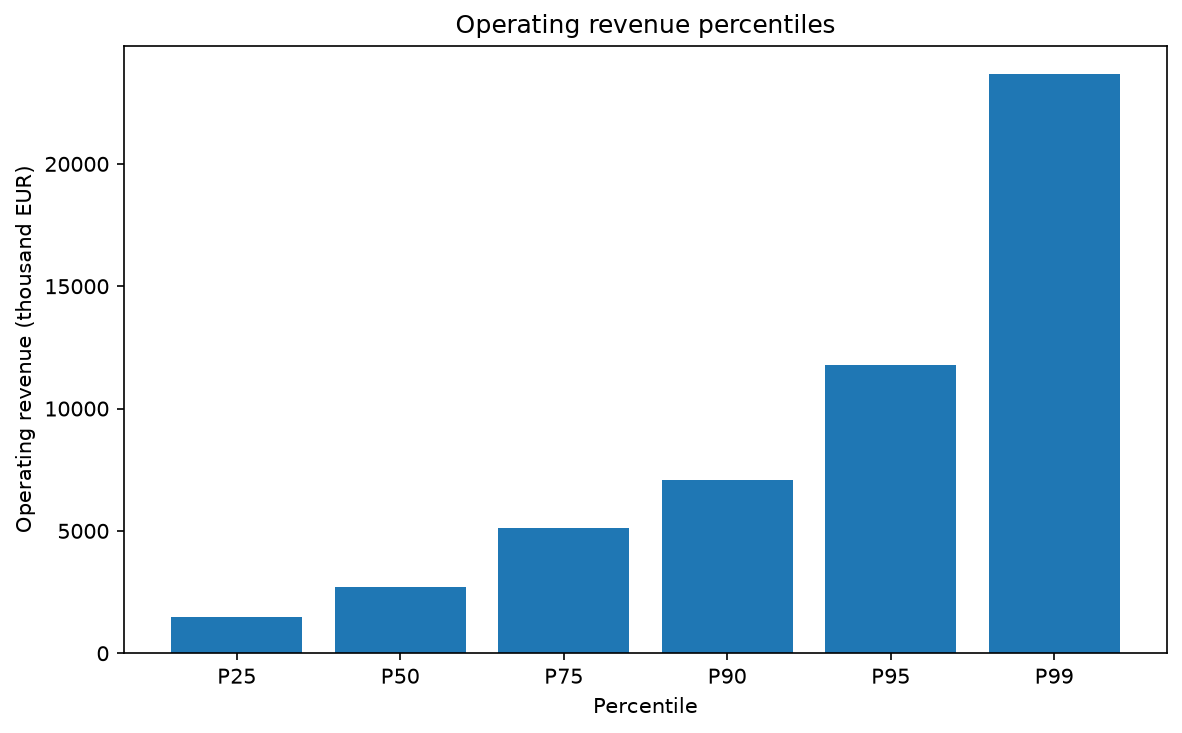

In [46]:
display(
    Image(
        filename=str(
            FIGURES_DIRECTORY
            / "revenue_percentiles.png"
        )
    )
)

## 7. Revenue concentration

Revenue concentration measures the proportion of total operating revenue
generated by the largest companies.

A high Top-N share indicates that aggregate results are sensitive to the
performance of a limited number of companies. Concentration does not by itself
indicate poor data quality or weak financial performance.

In [47]:
revenue_concentration = result.get_table(
    "revenue_concentration"
)

revenue_concentration

,scope,top_n,companies_included,revenue_k_eur,concentration_rate
0,all,1,1,30615.704254,0.065385
1,all,2,2,55422.525005,0.118364
2,all,5,5,104264.871574,0.222675
3,all,10,10,156270.428160,0.333741
4,all,20,20,223921.955747,0.478222
5,all,50,50,357437.784050,0.763367
6,all,100,100,456583.832361,0.975110


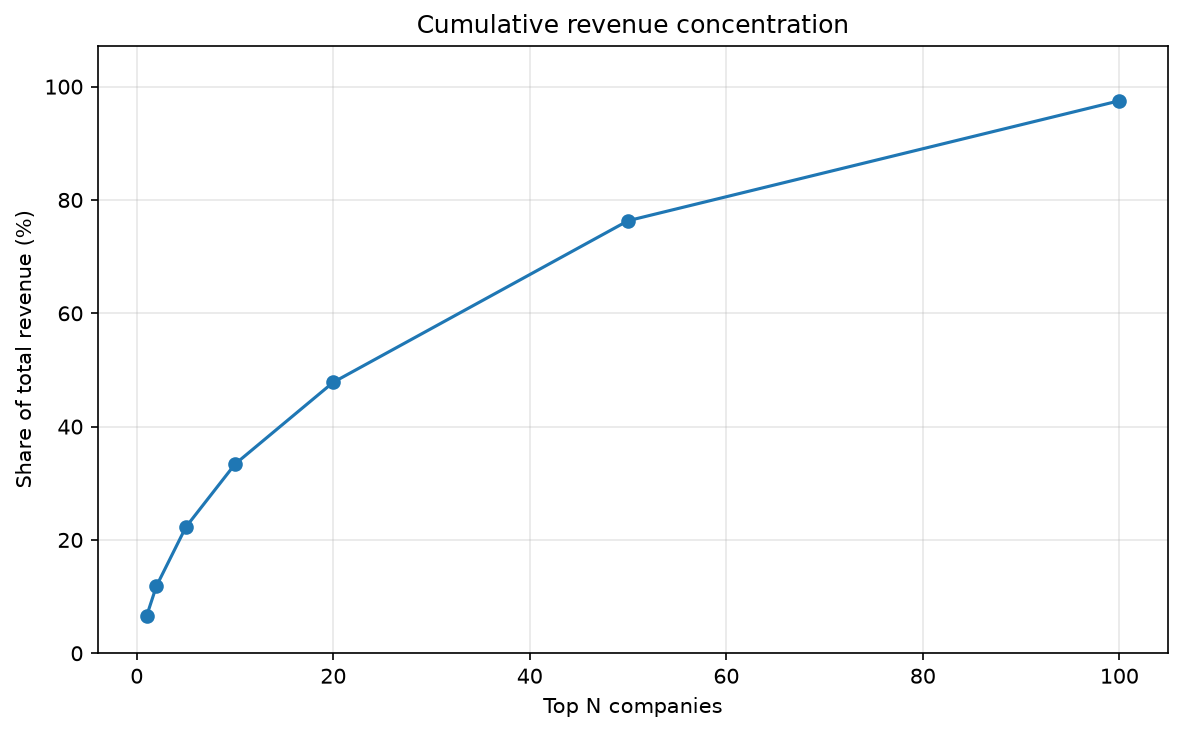

In [48]:
display(
    Image(
        filename=str(
            FIGURES_DIRECTORY
            / "revenue_concentration.png"
        )
    )
)

## 8. Synthetic company ranking

The following ranking contains only fictional companies generated by the
public data simulator. The ranking demonstrates the analytical functionality
without disclosing licensed SABI information or identifying real businesses.

In [49]:
company_ranking = result.get_table(
    "company_ranking"
)

company_ranking.head(10)

,rank,company_name,municipality,employees_latest,operating_revenue_latest_k_eur,ebitda_latest_k_eur,revenue_growth,ebitda_margin,legal_status,analytical_eligibility
0,1,SYNTHETIC VECTORLINE LOGISTICS 094 SL,ONDA,111,30615.704254,324.982790,0.080472,0.010615,no_adverse_marker,eligible
1,2,SYNTHETIC NORTHSTAR MANUFACTURING 073 SL,L'ALCORA,115,24806.820751,3746.741511,0.222026,0.151037,no_adverse_marker,eligible
2,3,SYNTHETIC VECTORLINE INDUSTRIES 010 SL,NULES,137,17609.393255,1844.839262,0.032986,0.104764,no_adverse_marker,eligible
3,4,SYNTHETIC PRIMEFIELD TECHNOLOGIES 057 SL,NULES,160,17193.894447,2468.231202,0.158222,0.143553,no_adverse_marker,eligible
4,5,SYNTHETIC AURORA OPERATIONS 072 SL,VINAROS,66,14039.058867,889.453409,0.169101,0.063356,no_adverse_marker,eligible
5,6,SYNTHETIC RIVERSTONE SYSTEMS 017 SL,VINAROS,105,12949.540983,2417.498090,-0.034365,0.186686,no_adverse_marker,eligible
6,7,SYNTHETIC RIVERSTONE OPERATIONS 065 SL,ONDA,87,11495.245582,1536.411774,0.072372,0.133656,no_adverse_marker,eligible
7,8,SYNTHETIC BRIGHTMILL SOLUTIONS 047 SL,NULES,59,10042.042137,1298.878507,-0.106903,0.129344,no_adverse_marker,eligible
8,9,SYNTHETIC CLEARPATH SOLUTIONS 044 SL,VILA-REAL,84,9583.019143,1191.388592,-0.089377,0.124323,no_adverse_marker,eligible
9,10,SYNTHETIC BRIGHTMILL INDUSTRIES 011 SL,VILA-REAL,70,7935.708741,-880.802666,0.009591,-0.110992,no_adverse_marker,eligible


In [50]:
assert company_ranking[
    "company_name"
].str.startswith(
    "SYNTHETIC "
).all()

print("Privacy check passed: all ranked companies are synthetic.")

Privacy check passed: all ranked companies are synthetic.


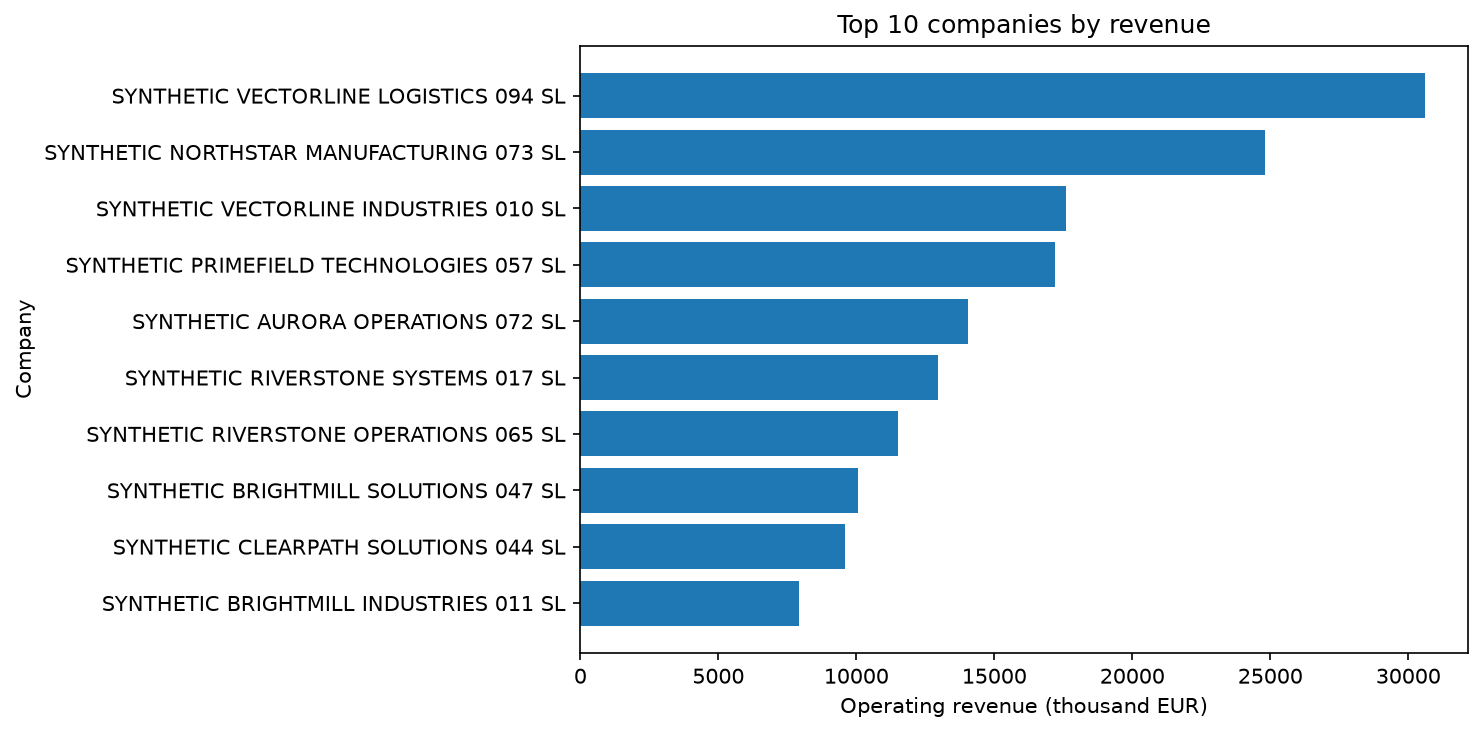

In [51]:
display(
    Image(
        filename=str(
            FIGURES_DIRECTORY
            / "company_ranking.png"
        )
    )
)

## 9. Geographic aggregation

Geographic analysis aggregates company count, employment, revenue and EBITDA
by municipality.

The private pipeline preserves both original and canonical municipality
labels through an auditable mapping process. The public dataset uses fictional
company observations associated with valid demonstration categories.

In [52]:
municipality_summary = result.get_table(
    "municipality_summary"
)

municipality_summary.head(15)

,municipality,company_count,employee_count,revenue_total_k_eur,ebitda_total_k_eur,median_revenue_k_eur,median_ebitda_margin,adverse_status_count,negative_ebitda_count,adverse_status_rate,negative_ebitda_rate
0,NULES,19,907,104624.747095,11517.439929,4304.491451,0.129344,1,3,0.052632,0.157895
1,ONDA,20,655,99888.837725,7105.120977,3853.237889,0.045146,2,5,0.100000,0.250000
2,VINAROS,17,469,60931.315745,2533.436383,1714.429447,0.054097,2,6,0.117647,0.352941
3,L'ALCORA,11,461,58363.259635,7580.247811,2873.719175,0.151037,0,1,0.000000,0.090909
4,VILA-REAL,16,511,56706.010883,5242.610212,2587.134620,0.115257,1,2,0.062500,0.125000
5,ALMASSORA,15,302,31576.938668,4760.473113,2091.710481,0.113735,1,2,0.066667,0.133333
6,BENICARLO,11,273,29354.506376,3840.550306,2721.039910,0.109784,0,0,0.000000,0.000000
7,CASTELLO DE LA PLANA,11,294,26792.707380,2993.907709,2714.006269,0.116963,1,2,0.090909,0.181818


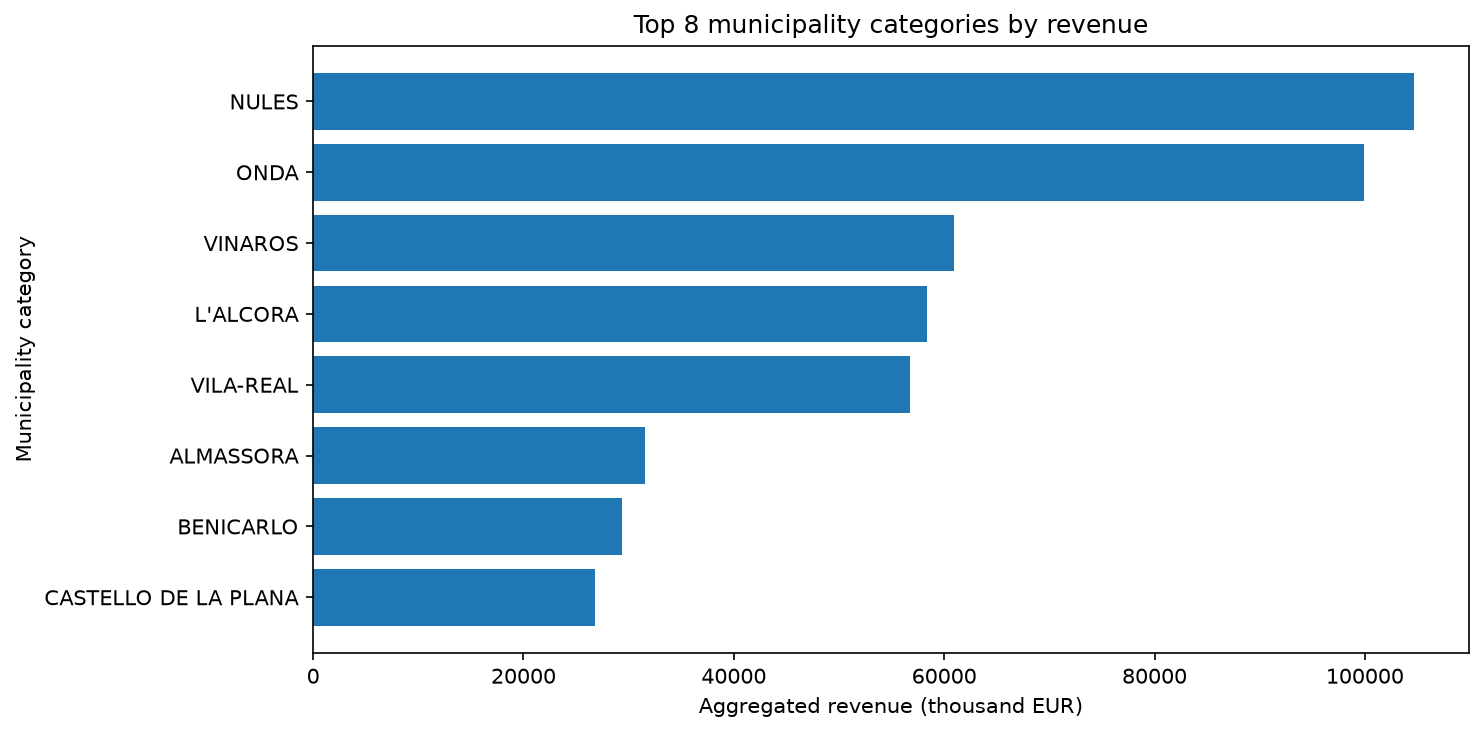

In [53]:
display(
    Image(
        filename=str(
            FIGURES_DIRECTORY
            / "municipality_summary.png"
        )
    )
)

In [54]:
assert result.source_name == "synthetic"
assert result.row_count == 120
assert result.final_column_count == 36
assert len(result.analytical_tables) == 7

assert result.source_dataframe[
    "company_name"
].str.startswith(
    "SYNTHETIC "
).all()

assert not result.quality_dataframe.empty
assert not scope_comparison.empty
assert not revenue_concentration.empty
assert not municipality_summary.empty

print("All notebook validation checks passed.")

All notebook validation checks passed.


## 10. Conclusions

1. Financial analysis should begin with schema and data-quality validation.
2. Missing financial information must not be interpreted as an economic zero.
3. Negative EBITDA is a business-risk signal, not automatically a data error.
4. Revenue concentration can materially influence aggregate conclusions.
5. Legal status and analytical eligibility should remain separate concepts.
6. Geographic normalization should preserve the original source label.
7. A synthetic public source enables reproducibility without redistributing
   licensed or confidential data.
8. Modular implementation and automated testing improve the reliability and
   auditability of financial analysis.

## 11. Limitations

- The public dataset is fully synthetic.
- The synthetic observations do not represent the Castellón economy.
- The results must not be used for investment, credit or legal decisions.
- Financial relationships are simplified for demonstration purposes.
- The private analysis combines each company's latest available reporting
  period and does not represent one homogeneous fiscal year.
- The current dataset does not contain complete balance-sheet, debt, cash,
  CAPEX or cash-flow information.
- Sector classifications are not yet incorporated into the public analysis.
- Absence of an adverse legal-status marker does not prove that a company is
  legally active.

## 12. Reproducibility

The repository includes:

- a deterministic synthetic-data generator;
- a fixed random seed;
- standardized public and private source adapters;
- an end-to-end pipeline;
- reproducible analytical exports;
- automated visualizations;
- automated tests covering schema, financial calculations, quality controls,
  analytics, geography, data sources, pipeline execution and exports.

The complete public workflow can be executed with:

```bash
python -m src.pipeline --source synthetic